In [1]:
cd ..

/home/sam/cc-net


/home/sam/anaconda3/envs/primal-dual/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
import graphlearning as gl
import numpy as np
import matplotlib.pyplot as plt
import sklearn.datasets as datasets
import torch
import scipy.sparse as sp
from scipy.sparse import coo_matrix, triu

import yaml
import models.models as Models
import losses.losses as Losses
import datasets.datasets as Datasets

from tqdm.notebook import tqdm, trange
import copy

In [3]:
def plot_graph(X, edge_index, ax):
    for i, j in zip(edge_index[0], edge_index[1]):
        ax.plot([X[i,0], X[j,0]], [X[i,1], X[j,1]], color='0.8', alpha=0.8, zorder=1) 
    ax.scatter(X[:, 0], X[:, 1], edgecolors='none', color='red', zorder=2)

In [4]:
def visualize_clusters(X, U, ax, point_size=8, label="Clustered data", show_membership=False):
    """Plot the loss curve and a grayscale scatter of the smoothed solution U."""
    fig = plt.figure(figsize=(10,4))
    if show_membership:
        for i in range(len(X)):
            ax.plot([X[i, 0], U[i, 0]], [X[i, 1], U[i, 1]], c='black', alpha=0.2)
    ax.scatter(X[:, 0], X[:, 1], s=8, edgecolors='none', alpha=0.5, label='original data')
    ax.scatter(U[:,0].cpu(), U[:,1].cpu(), s=point_size, alpha=0.9, c='0.4', label=label)
    
    

In [35]:
def load_model(model_cfg, model_pth):
    model_class = getattr(Models, model_config['model'])
    model = model_class(**model_config['cfg'])
    model = model.float()
    model_state = torch.load(model_pth, map_location='cpu')
    if 'model_state_dict' in model_state.keys():
        model.load_state_dict(model_state['model_state_dict'])
        return model
    model.load_state_dict(model_state)
    return model

def forward_pass(model, data, lam=1.0, iterations=1):
    src = data.edge_index[0]
    dst = data.edge_index[1]
    e_init = data.x[src] - data.x[dst]
    h = data.x.float()
    e = e_init.float()
    fid_terms = []
    tv_terms = []
    for _ in trange(iterations):    
        h, e, _ = model(h=h,
                     e=e, 
                     edge_index = data.edge_index, 
                     w=data.edge_attr.float(),
                     x=data.x.float())
        h = h.detach()
        e = e.detach()
        total, fidelity, fusion = get_primal_obj(h, data, lam)
        fid_terms.append(fidelity)
        tv_terms.append(fusion)
    return h, e, fid_terms, tv_terms

def iterate_inner(model, data, lam=1.0, model_iter=1):
    src = data.edge_index[0]
    dst = data.edge_index[1]
    e_init = data.x[src] - data.x[dst]
    h = data.x.float()
    e = e_init.float()
    fid_terms = []
    tv_terms = []
    


def get_primal_obj(U, data, lam):
    src = data.edge_index[0]
    dst = data.edge_index[1]
    w = data.edge_attr
    X = data.x
    return Losses.energy(U, X, src, dst, w, lam, return_parts=True)

In [36]:
exp_file = 'configs/single-runs/pdhg-knn-ls-reg.yaml'
with open(exp_file, "r") as f:
    exp_cfg = yaml.safe_load(f)

In [68]:
model_config = exp_cfg['model_config']
pth = '/data/sam/primal-dual/latent_space_regularized_energy_pdg/single_knn/EncodeProcessDecode/GraphPDHGNet/PDHGLayer_L1_H128_inN32_inE32_lam1.0_tau0.35_sig0.35_resid=False_steps=1_featDim=2/mmx9nahr/final.pt'
model_config['cfg']['lam'] = 1.0
model_config['cfg']['processor_cfg']['cfg']['num_layers'] = 1
model = load_model(model_config, pth)


In [72]:
datapth = '/data/sam/primal-dual/data/single_knn_base=two_moons_n_samples=200_n_graphs=100_noise=0.15-train.pt'
dataset = torch.load(datapth)

100%|████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 12.48it/s]


primal (tensor(11.5906, dtype=torch.float64), tensor(2.7881, dtype=torch.float64), tensor(8.8024, dtype=torch.float64))


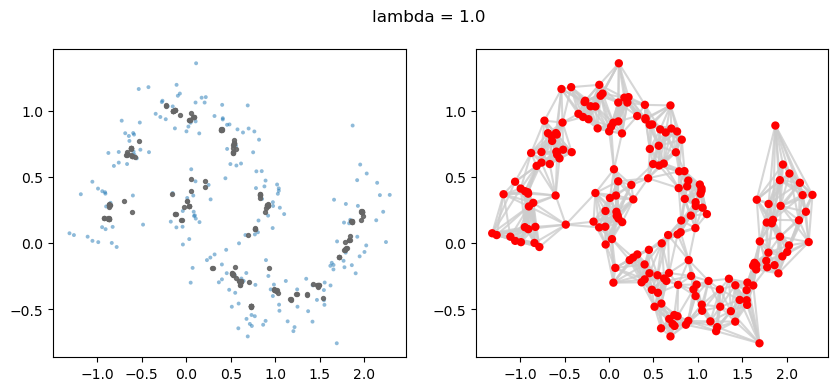

<Figure size 1000x400 with 0 Axes>

In [73]:
models = [model]
lambdas = [1.0]
example_graph = dataset[0]
for i in range(1):
    model = models[i]
    h, e, _, _ = forward_pass(model, example_graph)
    fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
    visualize_clusters(example_graph.x, h, axs[0])
    plot_graph(example_graph.x,example_graph.edge_index, axs[1])
    print("primal", get_primal_obj(h, example_graph, lam=lambdas[i]))
    fig.suptitle(f"lambda = {lambdas[i]}")

100%|████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00,  5.28it/s]


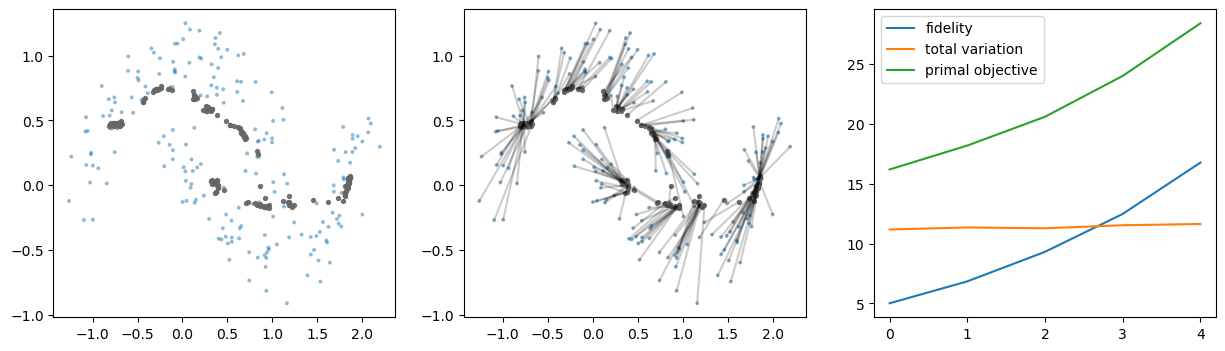

<Figure size 1000x400 with 0 Axes>

<Figure size 1000x400 with 0 Axes>

In [52]:
## Iterate model
import copy 
from tqdm import trange
g = copy.deepcopy(example_graph)
idx = 0
model = models[idx]
ITERS =5
model.recurrent_steps = 1
h, e, fidelity, tvs = forward_pass(model, g, lam=lambdas[idx], iterations=ITERS)
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(15, 4))
visualize_clusters(example_graph.x, h, axs[0], show_membership=False)
visualize_clusters(example_graph.x, h, axs[1], show_membership=True)
fidelity = np.array(fidelity)
tvs = np.array(tvs)
# plot_graph(example_graph.x,example_graph.edge_index, axs[1])
axs[2].plot(np.arange(ITERS), fidelity, label="fidelity")
axs[2].plot(np.arange(ITERS), tvs, label="total variation")
axs[2].plot(np.arange(ITERS), fidelity + tvs, label="primal objective")
axs[2].legend()

In [53]:
baseline_output = torch.load('/data/sam/primal-dual/data/multiple_knn_base=two_moons_n_samples=200_n_graphs=100_noise=0.15-train.pt_lam=1.0/output-jKM3cgGbMJ3EmmzZkPGRaQ.pt')


21.933207443424344


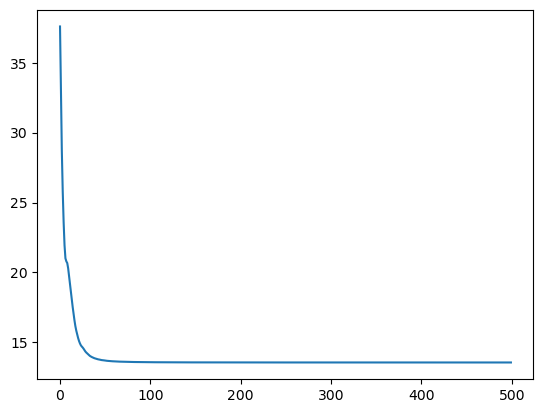

In [65]:
primal = np.array(baseline_output['primal_objs'])
plt.plot(np.arange(len(primal[0])), primal[0])
print(primal[0, 5])

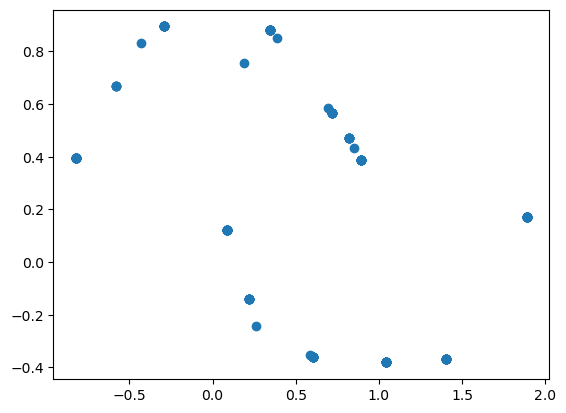

In [63]:
U = np.array(baseline_output['U'])
plt.scatter(U[0,:,  0], U[0,:,  1])


(tensor(505.7478, dtype=torch.float64), tensor(199.2486, dtype=torch.float64), tensor(306.4993, dtype=torch.float64))


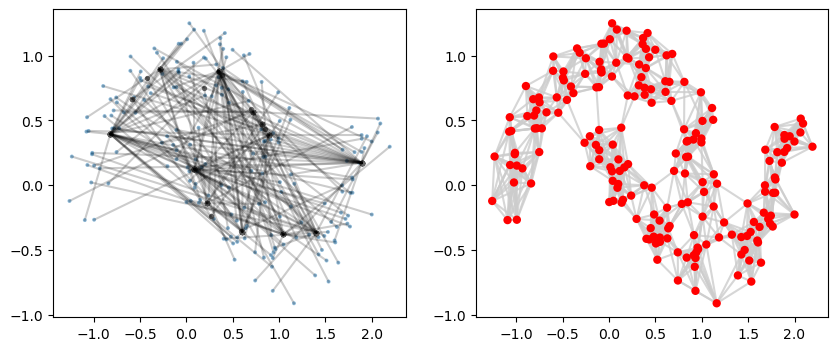

<Figure size 1000x400 with 0 Axes>

In [54]:
baseline_U = baseline_output['U'][0]

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
visualize_clusters(example_graph.x, baseline_U, axs[0], show_membership=True)
plot_graph(example_graph.x,example_graph.edge_index, axs[1])
print(get_primal_obj(baseline_U, example_graph, lam=1.0))

In [28]:
exp_file = 'configs/single-runs/best-gat-single.yaml'
with open(exp_file, "r") as f:
    exp_cfg = yaml.safe_load(f)

In [29]:
pth = '/data/sam/primal-dual/energy/multiple_knn/EncodeProcessDecode/GNNBaseline/GATConv_L2_H128_inN32_inE32_lam2.0_tau0.35_sig0.35_resid=False_steps=1_featDim=2/j6qvj0vv/final.pt'
model_config = exp_cfg['model_config']
model = load_model(model_config, pth)


100%|████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 12.57it/s]


(tensor(23.1085, dtype=torch.float64), tensor(4.3559, dtype=torch.float64), tensor(18.7526, dtype=torch.float64))


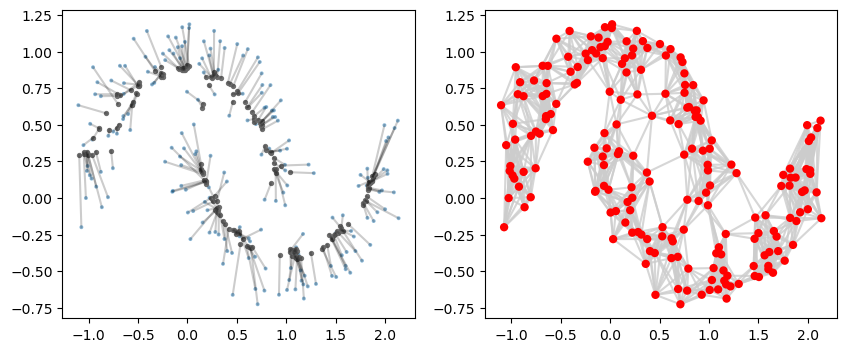

<Figure size 1000x400 with 0 Axes>

In [42]:
h, e, _, _ = forward_pass(model, example_graph)
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
visualize_clusters(example_graph.x, h, axs[0], show_membership=True)
plot_graph(example_graph.x,example_graph.edge_index, axs[1])
print(get_primal_obj(h, example_graph, lam=1.0))